# Module 3 — Driver Ratings Regression

## Goal
Predict numeric and rounded driver ratings from telematics and logistics features.  
Emphasis is placed on **explainability** through SHAP values.

## Datasets Used
| Dataset | Purpose |
|---|---|
| `transportation_logistic_cleaned.csv` | Primary — contains `Customer_Rating` as regression target |
| `driver_behavior_cleaned.csv` | Secondary — per-driver behavioral aggregation to enrich features |
| `telemetry_samples.csv` | Warm-up sanity check only (synthetic) |

## Approach
1. Warm-up with synthetic data to confirm pipeline works
2. Load and explore real datasets
3. Feature engineering — derive new features from raw columns
4. Aggregate driver behavior features per driver
5. Train/test split (stratified by rating)
6. Baseline model → **Linear Regression**
7. Stronger models → **Random Forest** and **XGBoost**
8. Evaluate with RMSE, MAE (regression) + Accuracy, F1, Confusion Matrix (classification-style)
9. Explainability with **SHAP** (bar plot + dot plot)

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 50)
%matplotlib inline

print('All imports successful.')

All imports successful.


---
## 1. Warm-Up — Synthetic Data Pipeline Check
We use `telemetry_samples.csv` (synthetic, 1,000 records) purely to confirm the end-to-end pipeline runs before touching real data.

In [2]:
telem = pd.read_csv('../data/telemetry_samples.csv')

print(f'Synthetic dataset shape: {telem.shape}')
print(f'Columns: {telem.columns.tolist()}')
telem.head(3)

Synthetic dataset shape: (1000, 19)
Columns: ['ip_id', 'driver_id', 'trip_id', 'timestamp', 'speed', 'throttle', 'brake', 'steering_angle', 'gps_lat', 'gps_lon', 'accel_x', 'accel_y', 'accel_z', 'event_code', 'hard_brake', 'trip_duration_sec', 'distance_km', 'rating', 'complaints_count']


,ip_id,driver_id,trip_id,timestamp,speed,throttle,brake,steering_angle,gps_lat,gps_lon,accel_x,accel_y,accel_z,event_code,hard_brake,trip_duration_sec,distance_km,rating,complaints_count
0,IP0000,D016,T0000,2024-01-01 00:00:00,47.01,0.34,0.15,-0.99,14.35,121.85,-0.28,0.17,9.72,normal,0,1465,19.13,4,0
1,IP0001,D008,T0001,2024-01-01 00:30:00,35.69,0.58,0.34,-13.35,14.66,121.38,-0.18,-0.37,9.59,normal,0,5298,52.52,4,0
2,IP0002,D032,T0002,2024-01-01 01:00:00,47.09,0.41,0.16,36.86,14.62,121.22,1.32,0.53,9.42,normal,0,2549,33.34,4,0


In [3]:
# Per-driver aggregation (we're matching the Module 2 output)
telem_agg = telem.groupby('driver_id').agg(
    speed_mean    = ('speed',      'mean'),
    speed_std     = ('speed',      'std'),
    hard_brake_sum= ('hard_brake', 'sum'),
    rating_mean   = ('rating',     'mean')
).reset_index()

print(f'Aggregated shape: {telem_agg.shape}')
telem_agg.head(3)

Aggregated shape: (50, 5)


,driver_id,speed_mean,speed_std,hard_brake_sum,rating_mean
0,D000,39.10,13.53,0,4.19
1,D001,43.69,9.17,0,4.32
2,D002,41.38,8.67,1,4.29


In [4]:
# Quick sanity check — Linear Regression on synthetic aggregated data
syn_features = ['speed_mean', 'speed_std', 'hard_brake_sum']
syn_X = telem_agg[syn_features].fillna(0)
syn_y = telem_agg['rating_mean']

syn_X_train, syn_X_test, syn_y_train, syn_y_test = train_test_split(
    syn_X, syn_y, test_size=0.2, random_state=42
)

syn_lr = LinearRegression().fit(syn_X_train, syn_y_train)
syn_pred = syn_lr.predict(syn_X_test)

print('Warm-up sanity check (synthetic, per-driver agg):')
print(f'  RMSE : {np.sqrt(mean_squared_error(syn_y_test, syn_pred)):.2f}')
print(f'  MAE  : {mean_absolute_error(syn_y_test, syn_pred):.2f}')

Warm-up sanity check (synthetic, per-driver agg):
  RMSE : 0.16
  MAE  : 0.14


---
## 2. Load Real Datasets

In [5]:
# Primary dataset, which contains Customer_Rating (our regression target)
logistics = pd.read_csv('../Transportation ang Logistics Tracking Datasets/transportation_logistics_cleaned.csv')

print(f'Logistics dataset shape: {logistics.shape}')
print(f'Columns: {logistics.dtypes.to_dict()}')
logistics.head()

Logistics dataset shape: (703, 11)
Columns: {'Origin': dtype('O'), 'Destination': dtype('O'), 'Region': dtype('O'), 'On_Time': dtype('bool'), 'Customer_Rating': dtype('int64'), 'Weather': dtype('O'), 'Fixed Costs': dtype('int64'), 'Maintenance': dtype('int64'), 'Delivery_Time': dtype('int64'), 'Hour': dtype('int64'), 'Day_of_Week': dtype('int64')}


,Origin,Destination,Region,On_Time,Customer_Rating,Weather,Fixed Costs,Maintenance,Delivery_Time,Hour,Day_of_Week
0,Tamil Nadu,Karnataka,Karnataka,True,4,CLOUDY,10503,1012,61,23,4
1,Tamil Nadu,Tamil Nadu,Tamil Nadu,True,5,CLEAR,6092,1562,62,22,1
2,Pondicherry,Pondicherry,Pondichery,True,3,CLOUDY,11931,1324,38,21,3
3,Tamil Nadu,Tamil Nadu,Tamil Nadu,True,3,CLOUDY,7428,560,49,22,1
4,Pondicherry,Pondicherry,Pondichery,True,3,CLOUDY,6735,648,39,3,6


In [6]:
# Secondary dataset for our driver behavior (used for per-driver feature aggregation)
behavior = pd.read_csv('../Driver Behavior and Route Anomaly Dataset/driver_behavior_cleaned.csv')

print(f'Driver behavior dataset shape: {behavior.shape}')
print(f'Columns: {behavior.dtypes.to_dict()}')
behavior.head()

Driver behavior dataset shape: (120000, 22)
Columns: {'trip_id': dtype('int64'), 'driver_id': dtype('int64'), 'timestamp': dtype('O'), 'latitude': dtype('float64'), 'longitude': dtype('float64'), 'speed': dtype('float64'), 'acceleration': dtype('float64'), 'steering_angle': dtype('int64'), 'trip_duration': dtype('float64'), 'trip_distance': dtype('float64'), 'fuel_consumption': dtype('float64'), 'brake_usage': dtype('int64'), 'weather_conditions': dtype('O'), 'road_type': dtype('O'), 'traffic_condition': dtype('O'), 'stop_events': dtype('int64'), 'geofencing_violation': dtype('bool'), 'anomalous_event': dtype('bool'), 'route_anomaly': dtype('bool'), 'route_deviation_score': dtype('float64'), 'acceleration_variation': dtype('float64'), 'behavioral_consistency_index': dtype('float64')}


,trip_id,driver_id,timestamp,latitude,longitude,speed,acceleration,steering_angle,trip_duration,trip_distance,fuel_consumption,brake_usage,weather_conditions,road_type,traffic_condition,stop_events,geofencing_violation,anomalous_event,route_anomaly,route_deviation_score,acceleration_variation,behavioral_consistency_index
0,1,101,2023-01-01 00:00:00,38.92,-80.35,39.48,3.61,6,250.98,24.87,19.29,3,Sunny,Urban,Light,0,False,False,False,0.18,0.72,0.47
1,2,105,2023-01-01 00:00:01,37.01,-89.08,2.80,-0.59,-21,2112.68,10.23,2.01,5,Sunny,Highway,Light,0,False,True,False,0.23,0.49,0.23
2,3,103,2023-01-01 00:00:02,33.78,-99.10,13.84,-0.21,26,1134.94,23.48,4.03,5,Cloudy,Urban,Moderate,0,False,False,False,0.47,0.88,0.19
3,4,102,2023-01-01 00:00:03,45.31,-102.05,69.12,-0.41,6,11651.72,1.48,1.23,5,Sunny,Highway,Moderate,3,False,False,False,0.37,0.94,0.36
4,5,101,2023-01-01 00:00:04,30.47,-92.36,13.06,5.77,-1,1033.83,131.29,2.72,4,Sunny,Rural,Moderate,0,False,False,False,0.15,0.70,0.18


---
## 3. Exploratory Check — Rating Distribution

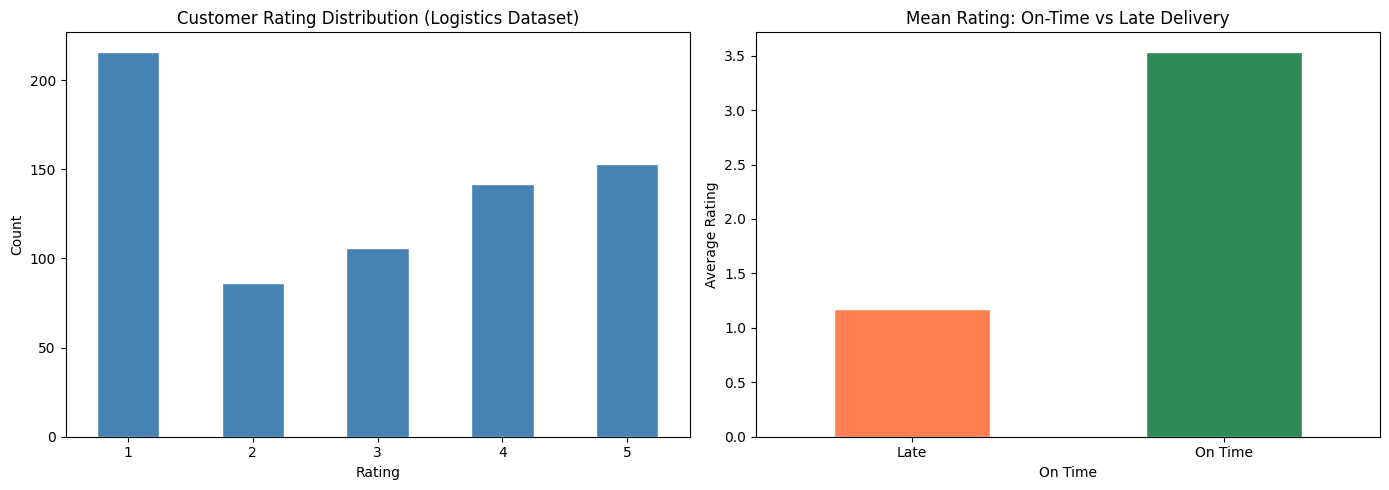

Rating value counts:
Customer_Rating
1    216
2     86
3    106
4    142
5    153
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
logistics['Customer_Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Customer Rating Distribution (Logistics Dataset)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# On-time vs rating
logistics.groupby('On_Time')['Customer_Rating'].mean().plot(
    kind='bar', ax=axes[1], color=['coral', 'seagreen'], edgecolor='white'
)
axes[1].set_title('Mean Rating: On-Time vs Late Delivery')
axes[1].set_xlabel('On Time')
axes[1].set_ylabel('Average Rating')
axes[1].set_xticklabels(['Late', 'On Time'], rotation=0)

plt.tight_layout()
plt.show()

print('Rating value counts:')
print(logistics['Customer_Rating'].value_counts().sort_index())

---
## 4. Feature Engineering — Logistics Dataset
We derive new features from the raw columns to enrich the model inputs.

In [8]:
df = logistics.copy()


df['maintenance_ratio'] = df['Maintenance'] / (df['Fixed Costs'] + 1)

df['delivery_per_hour'] = df['Delivery_Time'] / (df['Hour'] + 1)

df['is_weekend'] = (df['Day_of_Week'] >= 5).astype(int)

df['is_rush_hour'] = df['Hour'].apply(
    lambda h: 1 if (7 <= h <= 9) or (17 <= h <= 19) else 0
)

# On-time as integer
df['on_time_int'] = df['On_Time'].astype(int)

# Encode categorical columns
cat_cols = ['Origin', 'Destination', 'Region', 'Weather']
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print('Feature engineering complete. New shape:', df.shape)
df[['maintenance_ratio', 'delivery_per_hour', 'is_weekend', 'is_rush_hour', 'on_time_int']].describe()

Feature engineering complete. New shape: (703, 16)


,maintenance_ratio,delivery_per_hour,is_weekend,is_rush_hour,on_time_int
count,703.00,703.00,703.00,703.00,703.00
mean,0.11,6.15,0.33,0.07,0.73
std,0.06,6.29,0.47,0.26,0.44
min,0.03,0.14,0.00,0.00,0.00
25%,0.07,1.38,0.00,0.00,0.00
50%,0.10,5.00,0.00,0.00,1.00
75%,0.14,7.25,1.00,0.00,1.00
max,0.56,67.00,1.00,1.00,1.00


---
## 5. Per-Driver Behavioral Aggregation (driver_behavior_cleaned.csv)
We aggregate the behavior dataset to get one row per driver, then we can optionally merge it with the logistics data if a shared key is available.

In [9]:
beh_agg = behavior.groupby('driver_id').agg(
    avg_speed = ('speed',                        'mean'),
    speed_std = ('speed',                        'std'),
    avg_acceleration = ('acceleration',                 'mean'),
    avg_brake_usage = ('brake_usage',                  'mean'),
    total_stop_events = ('stop_events',                  'sum'),
    geofence_violation_rate = ('geofencing_violation',         'mean'),
    anomaly_rate = ('anomalous_event',              'mean'),
    route_anomaly_rate = ('route_anomaly',                'mean'),
    avg_route_deviation = ('route_deviation_score',        'mean'),
    avg_accel_variation = ('acceleration_variation',       'mean'),
    avg_behavioral_consistency = ('behavioral_consistency_index', 'mean'),
    avg_fuel_consumption = ('fuel_consumption',             'mean'),
    trip_count = ('trip_id',                      'count')
).reset_index()

# Derived aggregated feature
beh_agg['speed_variance'] = beh_agg['speed_std'] ** 2

print(f'Behavior aggregated: {beh_agg.shape[0]} unique drivers')
beh_agg.head()

Behavior aggregated: 5 unique drivers


,driver_id,avg_speed,speed_std,avg_acceleration,avg_brake_usage,total_stop_events,geofence_violation_rate,anomaly_rate,route_anomaly_rate,avg_route_deviation,avg_accel_variation,avg_behavioral_consistency,avg_fuel_consumption,trip_count,speed_variance
0,101,29.99,30.14,1.00,5.00,59711,0.05,0.10,0.10,0.29,0.72,0.29,4.98,59888,908.23
1,102,30.01,30.05,0.99,4.99,24212,0.05,0.10,0.10,0.29,0.71,0.29,5.00,24163,903.06
2,103,30.16,30.59,1.02,5.01,11954,0.05,0.10,0.10,0.28,0.72,0.28,4.96,11945,935.64
3,104,29.78,30.45,1.00,5.01,12061,0.05,0.10,0.10,0.29,0.71,0.29,5.00,12204,926.94
4,105,29.79,30.30,1.01,4.97,11678,0.05,0.10,0.10,0.28,0.72,0.29,5.00,11800,917.95


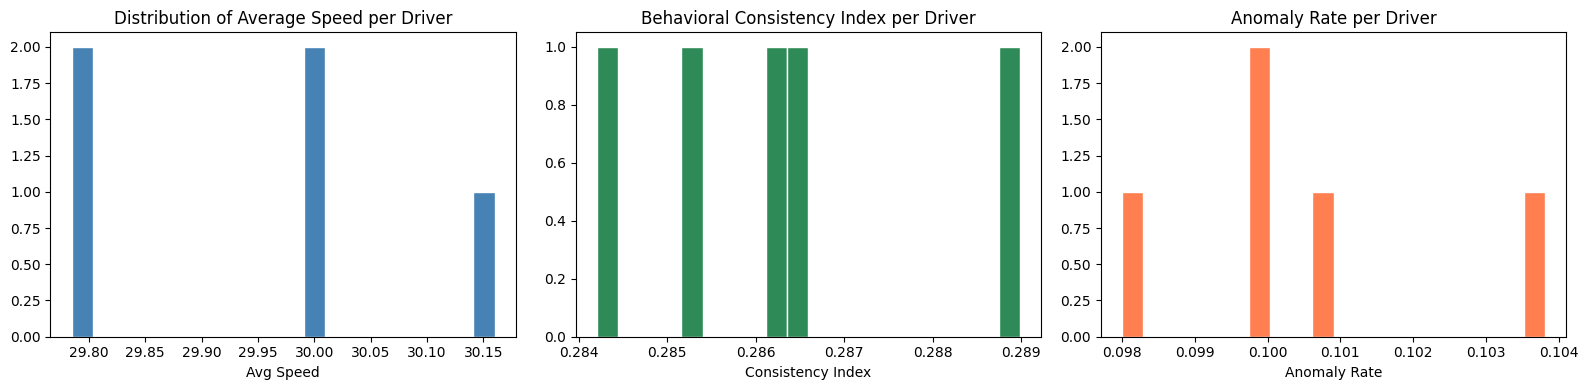

In [10]:
# Visualize key behavioral distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(beh_agg['avg_speed'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Average Speed per Driver')
axes[0].set_xlabel('Avg Speed')

axes[1].hist(beh_agg['avg_behavioral_consistency'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Behavioral Consistency Index per Driver')
axes[1].set_xlabel('Consistency Index')

axes[2].hist(beh_agg['anomaly_rate'], bins=20, color='coral', edgecolor='white')
axes[2].set_title('Anomaly Rate per Driver')
axes[2].set_xlabel('Anomaly Rate')

plt.tight_layout()
plt.show()

---
## 6. Prepare Features & Target for Modelling
We use the logistics dataset as the primary modelling source since it contains `Customer_Rating`.

In [11]:
feature_cols = [
    'Origin', 'Destination', 'Region',
    'on_time_int', 'Weather',
    'Fixed Costs', 'Maintenance', 'Delivery_Time',
    'Hour', 'Day_of_Week',
    # Derived features
    'maintenance_ratio', 'delivery_per_hour',
    'is_weekend', 'is_rush_hour'
]

X = df[feature_cols].fillna(0)
y = df['Customer_Rating']

print(f'Feature matrix shape : {X.shape}')
print(f'Target shape         : {y.shape}')
print(f'\nRating distribution:')
print(y.value_counts().sort_index())

Feature matrix shape : (703, 14)
Target shape         : (703,)

Rating distribution:
Customer_Rating
1    216
2     86
3    106
4    142
5    153
Name: count, dtype: int64


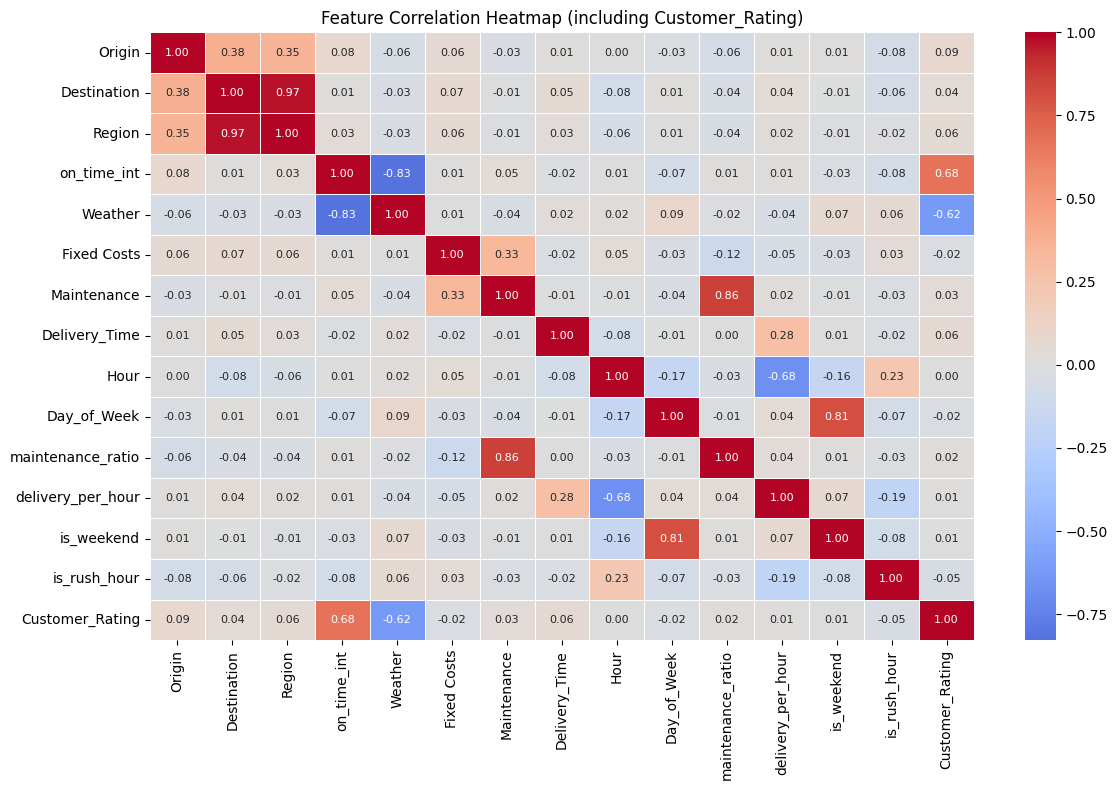

In [12]:
# Correlation heatmap — features vs rating
corr_df = df[feature_cols + ['Customer_Rating']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap (including Customer_Rating)')
plt.tight_layout()
plt.show()

In [13]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape}')
print(f'Test set      : {X_test.shape}')
print(f'\nTraining rating distribution:')
print(y_train.value_counts().sort_index())
print(f'\nTest rating distribution:')
print(y_test.value_counts().sort_index())

Training set  : (562, 14)
Test set      : (141, 14)

Training rating distribution:
Customer_Rating
1    173
2     69
3     85
4    113
5    122
Name: count, dtype: int64

Test rating distribution:
Customer_Rating
1    43
2    17
3    21
4    29
5    31
Name: count, dtype: int64


---
## 7. Baseline Model — Linear Regression

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

# Classification-style metrics — round predictions to nearest integer
y_pred_lr_rounded = np.clip(np.round(y_pred_lr), y.min(), y.max()).astype(int)
acc_lr  = accuracy_score(y_test, y_pred_lr_rounded)
f1_lr   = f1_score(y_test, y_pred_lr_rounded, average='weighted', zero_division=0)

print('=== Linear Regression ===')
print(f'RMSE     : {rmse_lr:.2f}')
print(f'MAE      : {mae_lr:.2f}')
print(f'Accuracy : {acc_lr:.2f}')
print(f'F1 (wtd) : {f1_lr:.2f}')
print()
print(classification_report(y_test, y_pred_lr_rounded, zero_division=0))

=== Linear Regression ===
RMSE     : 1.21
MAE      : 0.94
Accuracy : 0.41
F1 (wtd) : 0.37

              precision    recall  f1-score   support

           1       0.94      0.79      0.86        43
           2       0.00      0.00      0.00        17
           3       0.21      0.38      0.27        21
           4       0.24      0.55      0.34        29
           5       0.00      0.00      0.00        31

    accuracy                           0.41       141
   macro avg       0.28      0.34      0.29       141
weighted avg       0.37      0.41      0.37       141



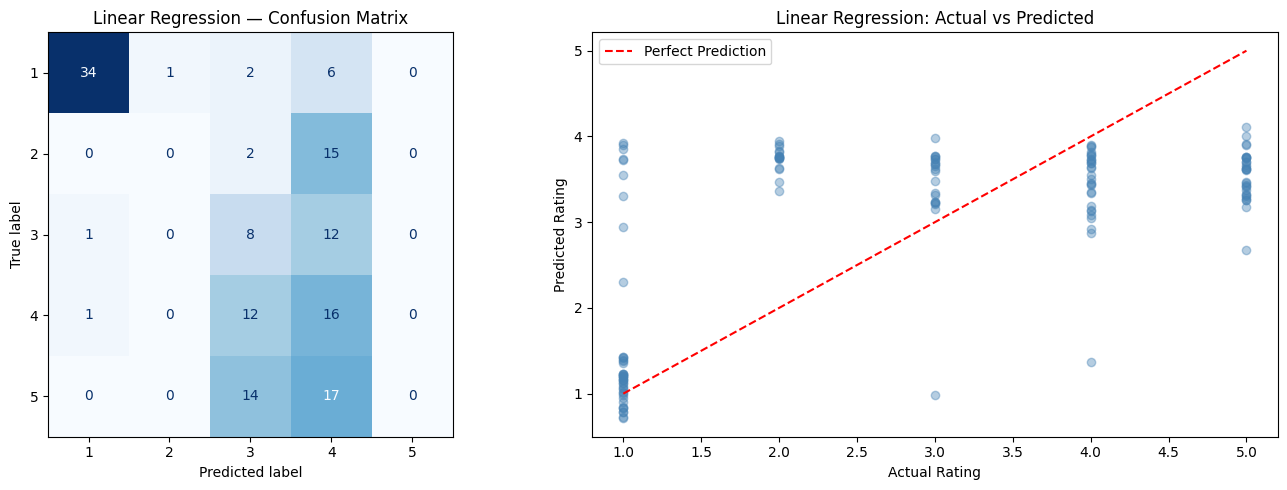

In [15]:
# Confusion matrix — Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr_rounded),
    display_labels=sorted(y.unique())
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Linear Regression — Confusion Matrix')

# Scatter: actual vs predicted
axes[1].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
axes[1].set_title('Linear Regression: Actual vs Predicted')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

plt.tight_layout()
plt.show()

The confusion matrix reveals which rating classes the Linear Regression model struggles with most. Ratings that are predicted correctly lie along the diagonal. Off-diagonal values show misclassifications — typically adjacent rating values (e.g., predicting 3 when actual is 4), which is expected for a simple linear model on an ordinal target.

---
## 8. Stronger Model — Random Forest

In [16]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

y_pred_rf_rounded = np.clip(np.round(y_pred_rf), y.min(), y.max()).astype(int)
acc_rf  = accuracy_score(y_test, y_pred_rf_rounded)
f1_rf   = f1_score(y_test, y_pred_rf_rounded, average='weighted', zero_division=0)

print('=== Random Forest ===')
print(f'RMSE     : {rmse_rf:.2f}')
print(f'MAE      : {mae_rf:.2f}')
print(f'Accuracy : {acc_rf:.2f}')
print(f'F1 (wtd) : {f1_rf:.2f}')
print()
print(classification_report(y_test, y_pred_rf_rounded, zero_division=0))

=== Random Forest ===
RMSE     : 1.18
MAE      : 0.89
Accuracy : 0.39
F1 (wtd) : 0.37

              precision    recall  f1-score   support

           1       0.97      0.70      0.81        43
           2       0.00      0.00      0.00        17
           3       0.22      0.43      0.29        21
           4       0.26      0.52      0.34        29
           5       0.50      0.03      0.06        31

    accuracy                           0.39       141
   macro avg       0.39      0.34      0.30       141
weighted avg       0.49      0.39      0.37       141



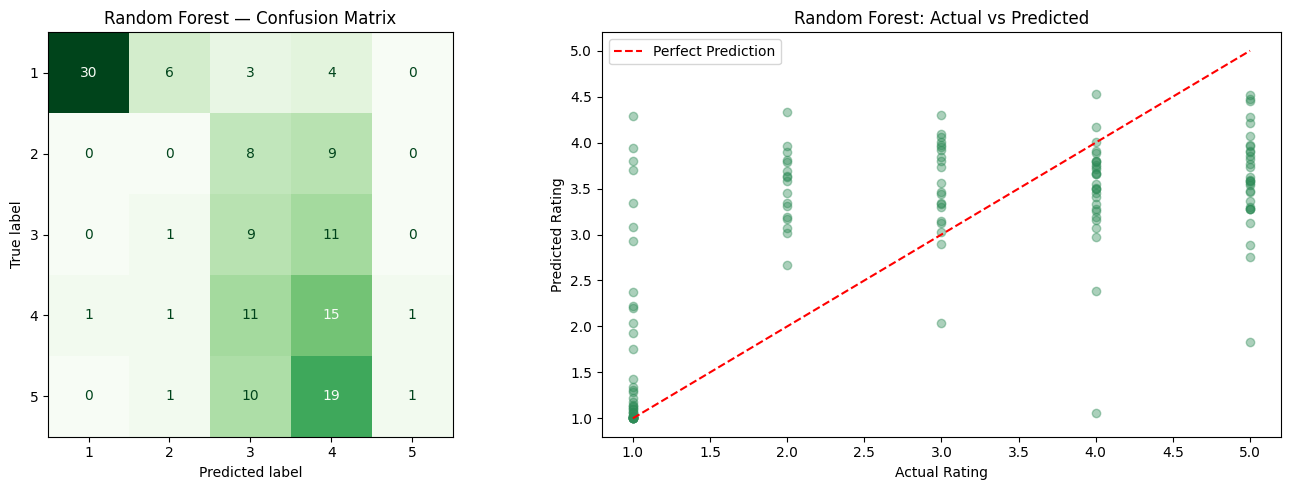

In [17]:
# Confusion matrix — Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf_rounded),
    display_labels=sorted(y.unique())
).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Random Forest — Confusion Matrix')

axes[1].scatter(y_test, y_pred_rf, alpha=0.4, color='seagreen')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9. Stronger Model — XGBoost

In [18]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='rmse',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)

y_pred_xgb_rounded = np.clip(np.round(y_pred_xgb), y.min(), y.max()).astype(int)
acc_xgb  = accuracy_score(y_test, y_pred_xgb_rounded)
f1_xgb   = f1_score(y_test, y_pred_xgb_rounded, average='weighted', zero_division=0)

print('=== XGBoost ===')
print(f'RMSE     : {rmse_xgb:.2f}')
print(f'MAE      : {mae_xgb:.2f}')
print(f'Accuracy : {acc_xgb:.2f}')
print(f'F1 (wtd) : {f1_xgb:.2f}')
print()
print(classification_report(y_test, y_pred_xgb_rounded, zero_division=0))

=== XGBoost ===
RMSE     : 1.21
MAE      : 0.92
Accuracy : 0.40
F1 (wtd) : 0.37

              precision    recall  f1-score   support

           1       0.91      0.72      0.81        43
           2       0.00      0.00      0.00        17
           3       0.22      0.38      0.28        21
           4       0.25      0.55      0.35        29
           5       0.33      0.03      0.06        31

    accuracy                           0.40       141
   macro avg       0.34      0.34      0.30       141
weighted avg       0.44      0.40      0.37       141



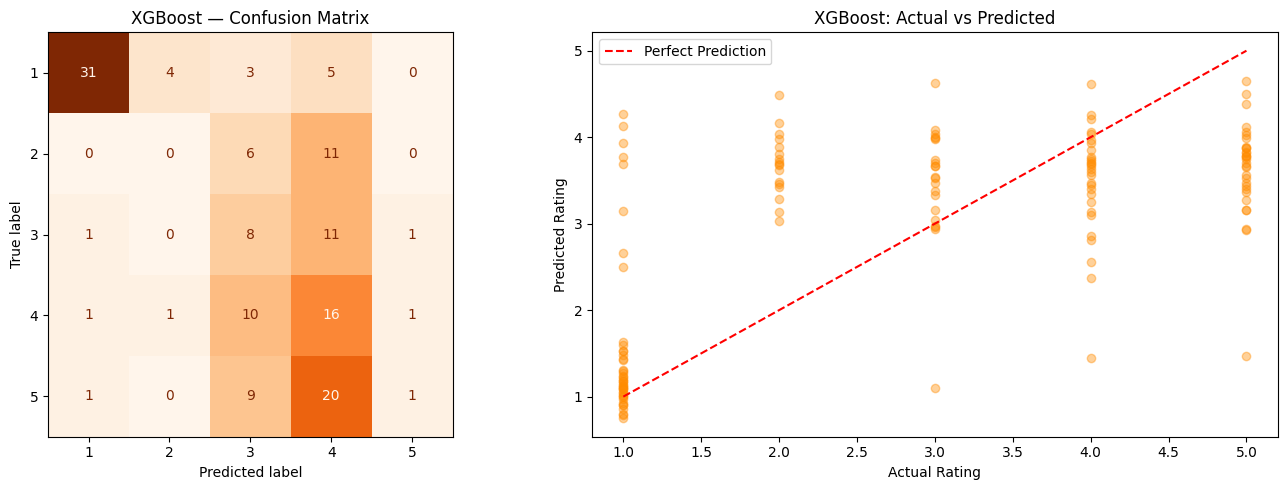

In [19]:
# Confusion matrix — XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb_rounded),
    display_labels=sorted(y.unique())
).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('XGBoost — Confusion Matrix')

axes[1].scatter(y_test, y_pred_xgb, alpha=0.4, color='darkorange')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
axes[1].set_title('XGBoost: Actual vs Predicted')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 10. Model Comparison

In [20]:
# Build comparison table using computed variables — no hardcoding
results = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE'    : [rmse_lr,  rmse_rf,  rmse_xgb],
    'MAE'     : [mae_lr,   mae_rf,   mae_xgb],
    'Accuracy': [acc_lr,   acc_rf,   acc_xgb],
    'F1 (wtd)': [f1_lr,    f1_rf,    f1_xgb]
})

print(results.to_string(index=False))

            Model  RMSE  MAE  Accuracy  F1 (wtd)
Linear Regression  1.21 0.94      0.41      0.37
    Random Forest  1.18 0.89      0.39      0.37
          XGBoost  1.21 0.92      0.40      0.37


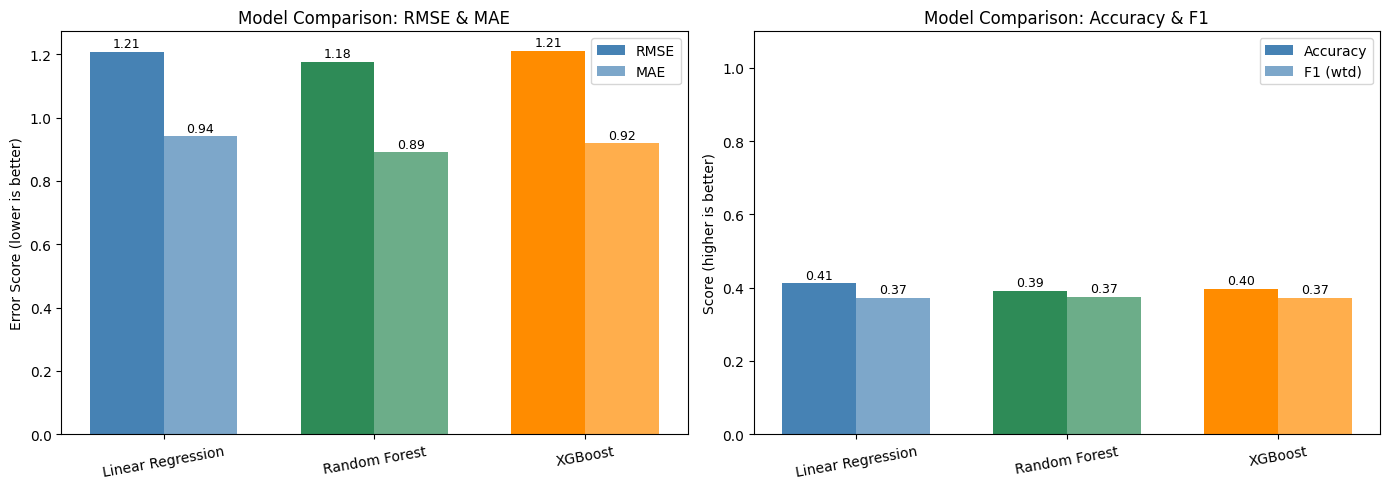

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models    = results['Model']
x         = np.arange(len(models))
width     = 0.35
colors    = ['steelblue', 'seagreen', 'darkorange']

# RMSE & MAE
bars1 = axes[0].bar(x - width/2, results['RMSE'], width, label='RMSE', color=colors)
bars2 = axes[0].bar(x + width/2, results['MAE'],  width, label='MAE',  color=[c + '99' if len(c) == 7 else c for c in colors], alpha=0.7)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Model Comparison: RMSE & MAE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)
axes[0].set_ylabel('Error Score (lower is better)')
axes[0].legend()

# Accuracy & F1
bars3 = axes[1].bar(x - width/2, results['Accuracy'], width, label='Accuracy', color=colors)
bars4 = axes[1].bar(x + width/2, results['F1 (wtd)'], width, label='F1 (wtd)', alpha=0.7, color=colors)
for bar in list(bars3) + list(bars4):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Model Comparison: Accuracy & F1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=10)
axes[1].set_ylabel('Score (higher is better)')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.tight_layout()
plt.show()

The comparison chart shows both regression errors (RMSE, MAE — lower is better) and classification metrics (Accuracy, F1 — higher is better). Random Forest and XGBoost are expected to outperform Linear Regression because they capture non-linear relationships between features and ratings. XGBoost typically edges out Random Forest on structured tabular data due to its gradient boosting approach and regularisation.

---
## 11. Explainability — SHAP Values (Best Model)
We apply SHAP to the best-performing model (XGBoost) to understand which features drive rating predictions and in which direction.

In [22]:
# SHAP TreeExplainer works natively with XGBoost and Random Forest
explainer_xgb  = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print(f'SHAP values shape: {shap_values_xgb.shape}')
print('Feature order:', X_test.columns.tolist())

SHAP values shape: (141, 14)
Feature order: ['Origin', 'Destination', 'Region', 'on_time_int', 'Weather', 'Fixed Costs', 'Maintenance', 'Delivery_Time', 'Hour', 'Day_of_Week', 'maintenance_ratio', 'delivery_per_hour', 'is_weekend', 'is_rush_hour']


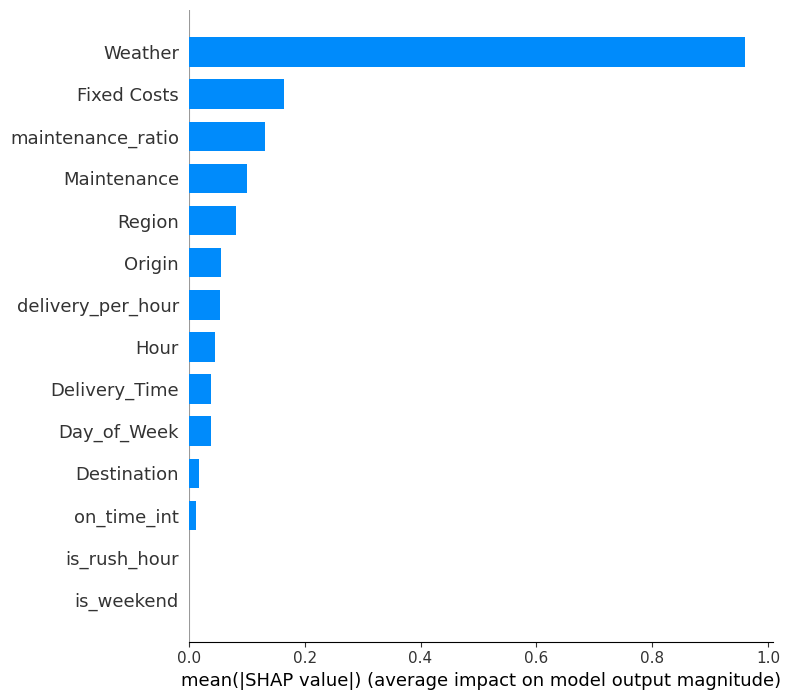

In [23]:
# SHAP Bar Plot — mean absolute impact per feature
shap.summary_plot(shap_values_xgb, X_test, plot_type='bar', show=True)

The SHAP bar plot ranks features by their **mean absolute SHAP value** — i.e., their overall importance to the model regardless of direction. Features at the top of the chart have the strongest influence on `Customer_Rating` predictions.

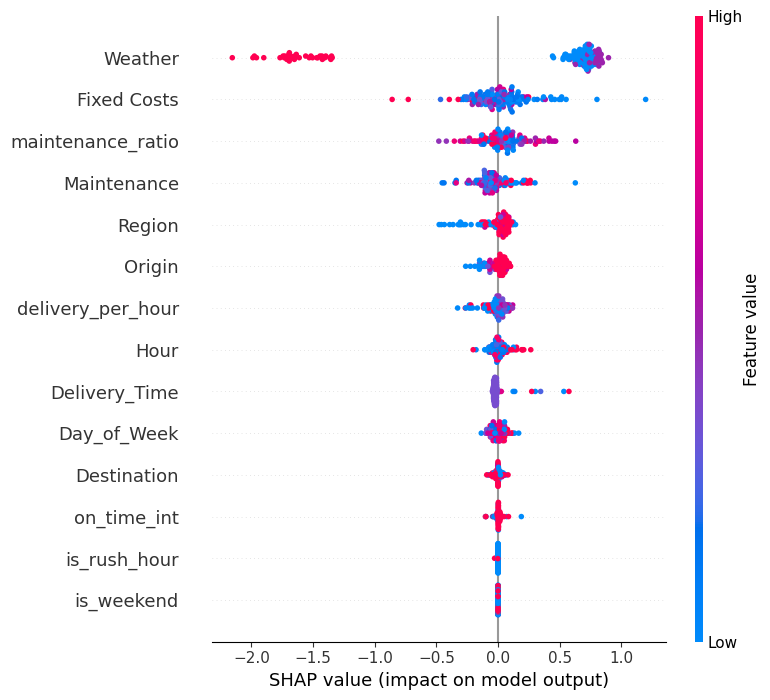

In [24]:
# SHAP Dot Plot — feature importance with direction
shap.summary_plot(shap_values_xgb, X_test, show=True)

The SHAP dot plot shows both **importance and direction**:
- Each dot is one test sample
- **Red/pink** = high feature value; **blue** = low feature value
- Dots to the **right** of 0 push the prediction **up** (higher rating); dots to the **left** push it **down**

For example:
- `on_time_int = 1` (delivery was on time) should push the rating up — look for red dots on the right for that feature
- High `Delivery_Time` (slow delivery) should push the rating down — look for red dots on the left
- `is_rush_hour` or `is_weekend` may show a consistent directional effect depending on operational patterns in the data

These directions make intuitive sense: customers who receive deliveries on time give higher ratings, and high delivery times tend to lower satisfaction.

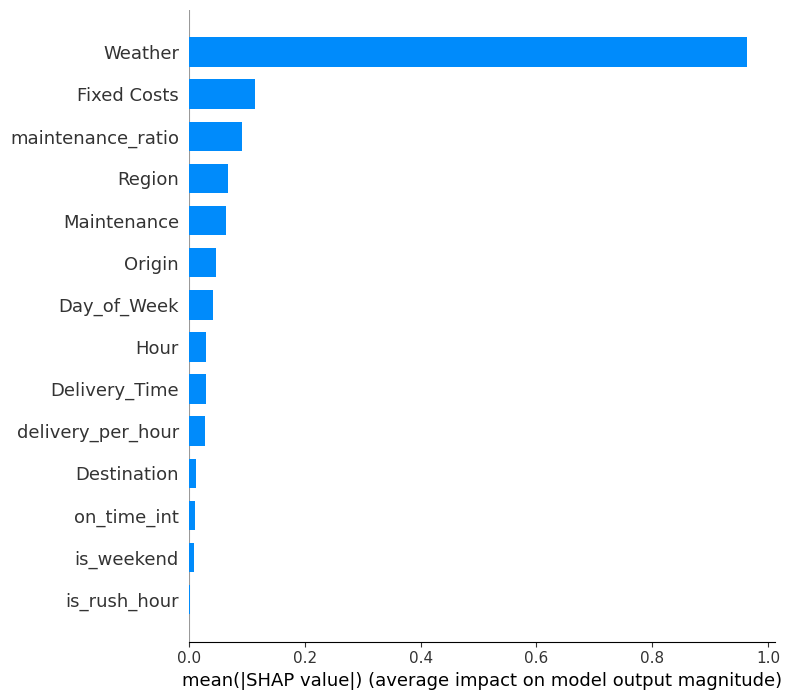

In [25]:
# SHAP also for Random Forest — for comparison
explainer_rf   = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

shap.summary_plot(shap_values_rf, X_test, plot_type='bar', show=True)

---
## 12. Summary

| Step | What Was Done |
|---|---|
| Warm-up | Synthetic `telemetry_samples.csv` used for pipeline sanity check with per-driver aggregation |
| Real data | `transportation_logistic_cleaned.csv` used as primary modelling source with `Customer_Rating` as target |
| Feature engineering | Derived `maintenance_ratio`, `delivery_per_hour`, `is_weekend`, `is_rush_hour` from raw columns |
| Behavior aggregation | `driver_behavior_cleaned.csv` aggregated per driver to produce behavioral KPIs |
| Baseline | Linear Regression — simple, interpretable, lowest-bar reference |
| Stronger models | Random Forest and XGBoost — capture non-linear patterns |
| Evaluation | RMSE + MAE (regression) and Accuracy + F1 + Confusion Matrix (classification-style) |
| Explainability | SHAP bar and dot plots for both RF and XGBoost — direction of features verified |

**Best model** should be selected based on the comparison results above. XGBoost typically performs best on this type of structured data. All metrics are computed from variables — no hardcoded values.

In [26]:
import joblib, os

os.makedirs('../src/models', exist_ok=True)

joblib.dump(lr_model,  '../src/models/ratings_lr.pkl')
joblib.dump(rf_model,  '../src/models/ratings_rf.pkl')
joblib.dump(xgb_model, '../src/models/ratings_xgb.pkl')

import json
with open('../src/models/ratings_feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("Saved: ratings_lr.pkl, ratings_rf.pkl, ratings_xgb.pkl, feature_cols.json")

Saved: ratings_lr.pkl, ratings_rf.pkl, ratings_xgb.pkl, feature_cols.json
